# Week 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Loan_default.csv")

## Missing Values

In [3]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

## Duplicate Rows

In [4]:
print(df.duplicated().sum())

0


## Remove Duplicates

In [5]:
df=df.drop_duplicates();print(df.shape)

(255347, 18)


## Data Types

In [6]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

## Numeric Columns

In [7]:
numeric_columns=df.select_dtypes(include=np.number).columns
print(numeric_columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'],
      dtype='object')


## Categorical Columns

In [8]:
category_columns=['gender','cholesterol','gluc','smoke','alco','active','cardio']
print(category_columns)

['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


## Boxplots

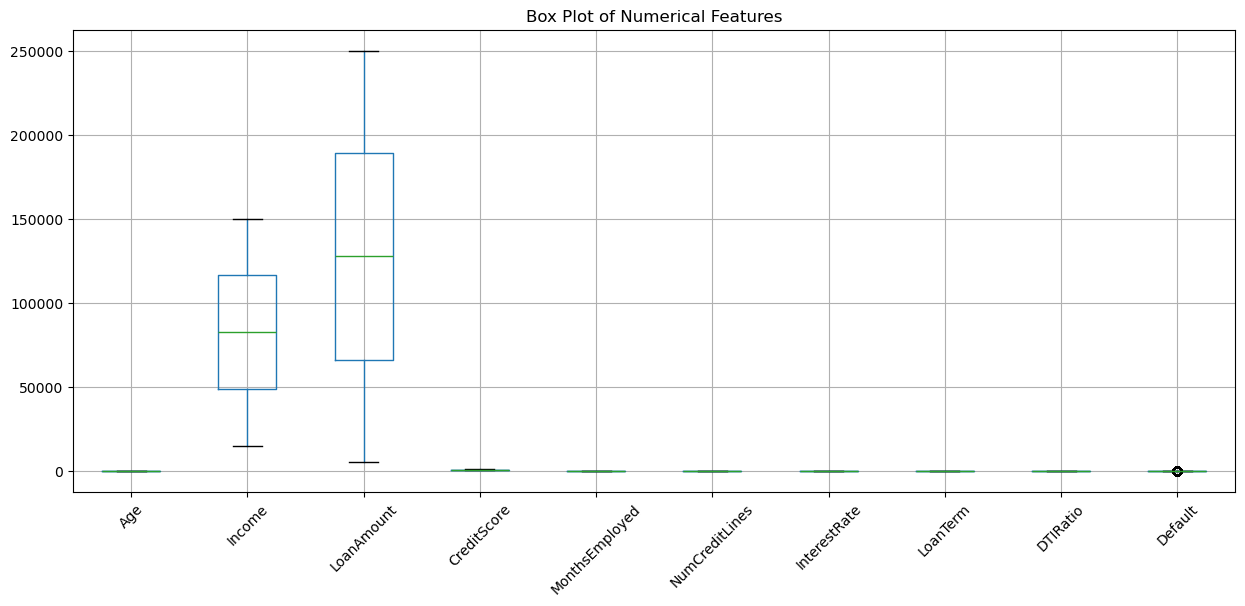

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,6))
df[numeric_columns].boxplot()
plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.show()


plt.figure(figsize=(12,5))

## Remove BP Outliers

In [10]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (225694, 18)


## IQR Function

In [14]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Removing Outliers:", df.shape)


Dataset Shape After Removing Outliers: (225694, 18)


## Apply IQR

In [15]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df

In [16]:
numeric_cols = [
    'Age', 'Income', 'LoanAmount', 'CreditScore',
    'MonthsEmployed', 'NumCreditLines',
    'InterestRate', 'LoanTerm', 'DTIRatio'
]

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

## Target Plot

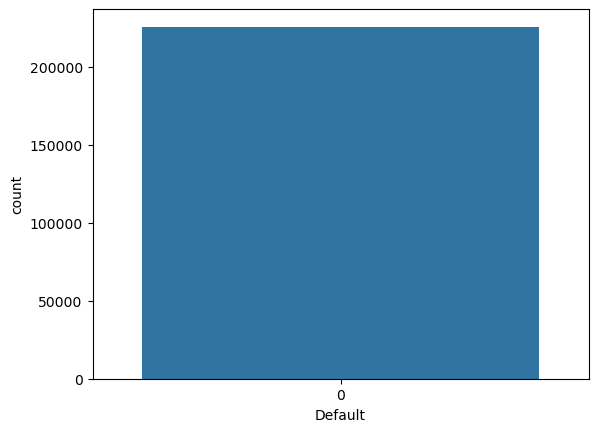

In [14]:
sns.countplot(data=df, x='Default')
plt.show()

## Age Histogram

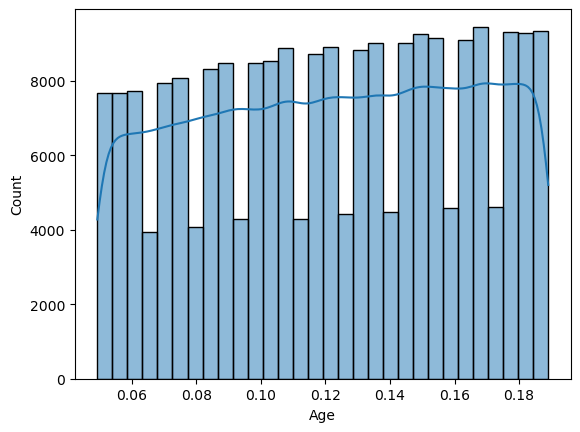

In [18]:
sns.histplot(df['Age']/365,bins=30,kde=True);plt.show()

## Heatmap

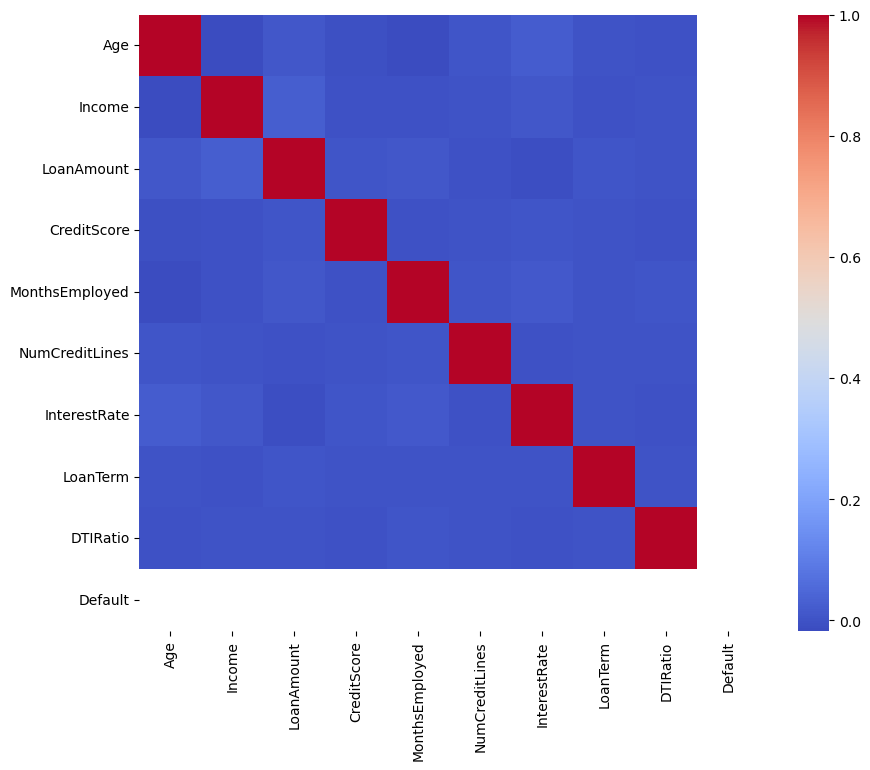

In [16]:
plt.figure(figsize=(10,8));sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm');plt.show()